Filtrado de spam en mensajes de texto (SMS)
===

* (45 min)

**Bibliografía.**
* Machine Learning with R. Brett Lantz, Packt Publishing, Second Edition, 2015.

## Definición del problema real

La recepción de publicidad no deseada a traves mensajes de texto usando SMS (Short Message Service) es un problema que afecta a muchos usuarios de teléfonos móviles. El problema radica en que los usuarios deben pagar por los mesajes recibidos, y por este motivo resulta muy importante que las compañías prestadoras del servicio puedan filtrar mensajes indeseados antes de enviarlos a su destinatario final. Los mensajes tienen una longitud máxima de 160 caracteres, por lo que el texto resulta poco para realizar la clasificación, en comparación con textos más largos (como los emails). Adicionalmente, los errores de digitación dificultan el proceso de detección automática.   

## Definición del problema en términos de los datos

La muestra contiene 5574 mensajes en inglés, no codificados y clasificados como legítimos (ham) o spam (http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/). El problema en términos de los datos consiste en clasificar si un mensaje SMS es legítico o spam, a partir del análisis de las palabras que contiente, partiendo del supuesto de que ciertas palabras que son más frecuentes dependiendo del tipo de mensaje. Esto implica que en la fase de preparación de los datos se deben extraer las palabras que contiene cada mensaje para poder realizar el análsis.

## Exploración

In [1]:
##
## Carga de los datos.
##
data <- read.csv("data/sms_spam.csv", stringsAsFactors = FALSE)

##
## Verificación de los datos cargados.
##
str(data)

'data.frame':	5574 obs. of  2 variables:
 $ type: chr  "ham" "ham" "spam" "ham" ...
 $ text: chr  "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..." "Ok lar... Joking wif u oni..." "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question("| __truncated__ "U dun say so early hor... U c already then say..." ...


In [2]:
##
## Se convierte la columna type, que contiene strings, en un factor.
##
data$type <- factor(data$type)
str(data$type)

 Factor w/ 2 levels "ham","spam": 1 1 2 1 1 2 1 1 2 2 ...


In [3]:
# Cantidad de casos para cada tipo de mensaje.
table(data$type)


 ham spam 
4827  747 

In [4]:
# Se convierte el conteo en probabilidades.
round(prop.table(table(data$type)) * 100, digits = 1)


 ham spam 
86.6 13.4 

## Metodología

Se usará Bayes discreto

## Preparación de los datos

In [6]:
##
## El paquete tm se usa para minería de texto
## install.packages("tm")
## install.packages("NLP")
## install.packages("SnowballC")
##
library(NLP)
library(tm)
library(SnowballC)

In [7]:
##
## Se crea un corpus que es una colección de documentos.
##
data_corpus <- VCorpus(VectorSource(data$text))
print(data_corpus)

<<VCorpus>>
Metadata:  corpus specific: 0, document level (indexed): 0
Content:  documents: 5574


In [8]:
# Se pueden seleccionar elementos particulares dentro del corpus.
inspect(data_corpus[1:2])

<<VCorpus>>
Metadata:  corpus specific: 0, document level (indexed): 0
Content:  documents: 2

[[1]]
<<PlainTextDocument>>
Metadata:  7
Content:  chars: 111

[[2]]
<<PlainTextDocument>>
Metadata:  7
Content:  chars: 29



In [9]:
# Para ver un mensaje de texto en particular se usa as.character
as.character(data_corpus[[1]])

[1] "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

In [10]:
# Para ver varios documentos se usa lapply
lapply(data_corpus[1:2], as.character)

$`1`
[1] "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

$`2`
[1] "Ok lar... Joking wif u oni..."

In [11]:
##
## Para ver el efecto de las transformaciones
## realizadas, a continuación se muestran los 
## mensajes originales y los transformados.
## Mensajes antes de realizar la limpieza.
##
lapply(data_corpus[1:3], as.character)

$`1`
[1] "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."

$`2`
[1] "Ok lar... Joking wif u oni..."

$`3`
[1] "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [12]:
##
## Se convierten todas las letras en minúsculas
##
data_corpus_clean <- tm_map(data_corpus, 
                            content_transformer(tolower))

##
## Se eliminan los dígitos
##
data_corpus_clean <- tm_map(data_corpus_clean,
                            removeNumbers)

##
## Se eliminan las stop-words
##
data_corpus_clean <- tm_map(data_corpus_clean,
                            removeWords, # funcion que remueve las palabras
                            stopwords()) # lista de palabras a remover

##
## Se remueve la puntuación.
##
data_corpus_clean <- tm_map(data_corpus_clean, 
                            removePunctuation)

##
## Se transforman a infinitivo las conjugaciones.
##
data_corpus_clean <- tm_map(data_corpus_clean, 
                            stemDocument)

##
## Se remueven espacios en blanco adicionales.
##
data_corpus_clean <- tm_map(data_corpus_clean, 
                            stripWhitespace)

In [13]:
##
## Mensajes despues de limpiar.
##
lapply(data_corpus_clean[1:3], as.character)

$`1`
[1] "go jurong point crazi avail bugi n great world la e buffet cine got amor wat"

$`2`
[1] "ok lar joke wif u oni"

$`3`
[1] "free entri wkli comp win fa cup final tkts st may text fa receiv entri questionstd txt ratetc appli s"

In [14]:
##
## Se crea la matriz de términos del documento
##
data_dtm <- DocumentTermMatrix(data_corpus_clean)

In [15]:
##
## Es posible crear la matriz de términos del documento
## sin pasar por el preprocesmiento previo y realizarlo
## directamente en la llamada a la función
##
data_dtm2 <- 
DocumentTermMatrix(data_corpus, 
                   control = list(tolower = TRUE, 
                                  removeNumbers = TRUE,
                                  stopwords = TRUE, 
                                  removePunctuation = TRUE,
                                  stemming = TRUE))

In [16]:
data_dtm

<<DocumentTermMatrix (documents: 5574, terms: 6592)>>
Non-/sparse entries: 42608/36701200
Sparsity           : 100%
Maximal term length: 40
Weighting          : term frequency (tf)

In [17]:
data_dtm2

<<DocumentTermMatrix (documents: 5574, terms: 6995)>>
Non-/sparse entries: 43713/38946417
Sparsity           : 100%
Maximal term length: 40
Weighting          : term frequency (tf)

In [18]:
##
## Creación de los conjuntos de entrenamiento y prueba.
##
X_train      <- data_dtm[1:4169, ]
X_test       <- data_dtm[4170:5559, ]
y_train_true <- data[1:4169, ]$type
y_test_true  <- data[4170:5559, ]$type

In [19]:
##
## Distribución de los datos en el conjunto de entrenamiento.
##
prop.table(table(y_train_true))

y_train_true
      ham      spam 
0.8647158 0.1352842 

In [20]:
##
## Distribución de los datos en el conjunto de prueba.
##
prop.table(table(y_test_true))

y_test_true
      ham      spam 
0.8697842 0.1302158 

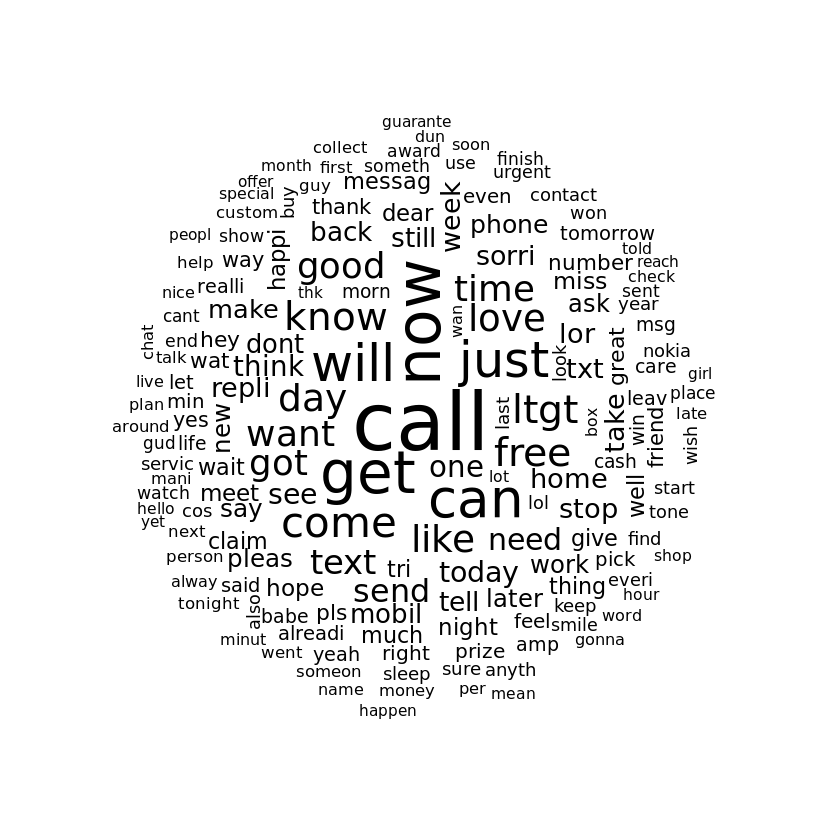

In [22]:
##
## En este caso es más útil visualizar 
## una nube que indique la frecuencia de las
## palabras
## install.packages("wordcloud")
## install.packages("RColorBrewer")
##
library(RColorBrewer)
library(wordcloud)
wordcloud(data_corpus_clean, 
          min.freq = 50,         # número de veces que debe aparecer una palabra
          random.order = FALSE)  # palabras más frecuentes en el centro

Warning message in tm_map.SimpleCorpus(corpus, tm::removePunctuation):
“transformation drops documents”Warning message in tm_map.SimpleCorpus(corpus, function(x) tm::removeWords(x, tm::stopwords())):
“transformation drops documents”

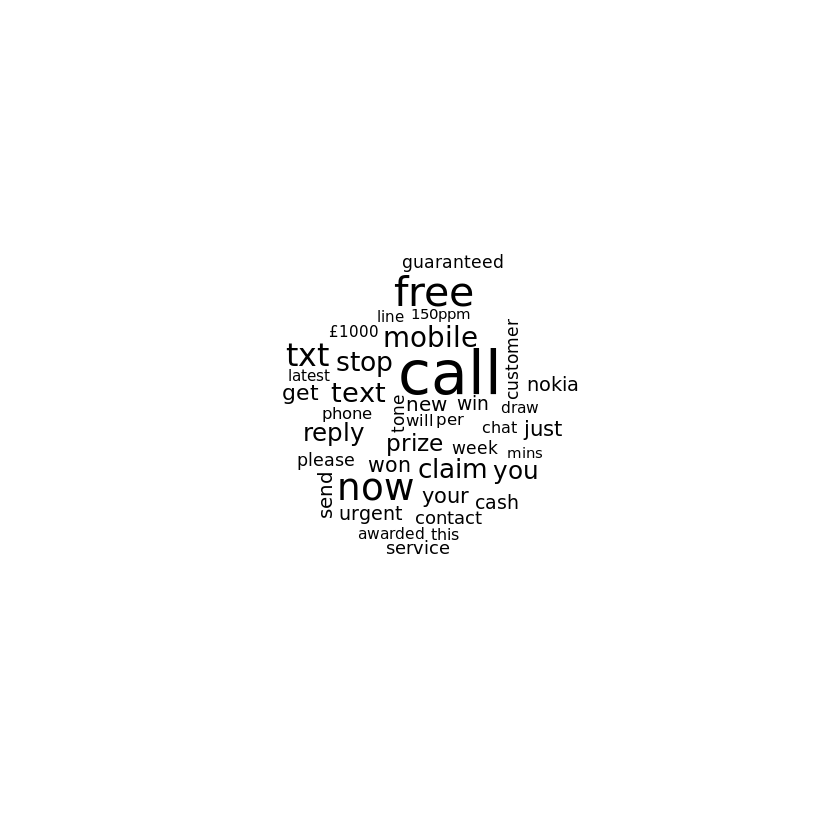

In [23]:
##
## Palabras que más aparecen en mensajes spam y válidos.
##
spam <- subset(data, type == "spam")
ham  <- subset(data, type == "ham")
wordcloud(spam$text, max.words = 40, scale = c(3, 0.5))

Warning message in tm_map.SimpleCorpus(corpus, tm::removePunctuation):
“transformation drops documents”Warning message in tm_map.SimpleCorpus(corpus, function(x) tm::removeWords(x, tm::stopwords())):
“transformation drops documents”

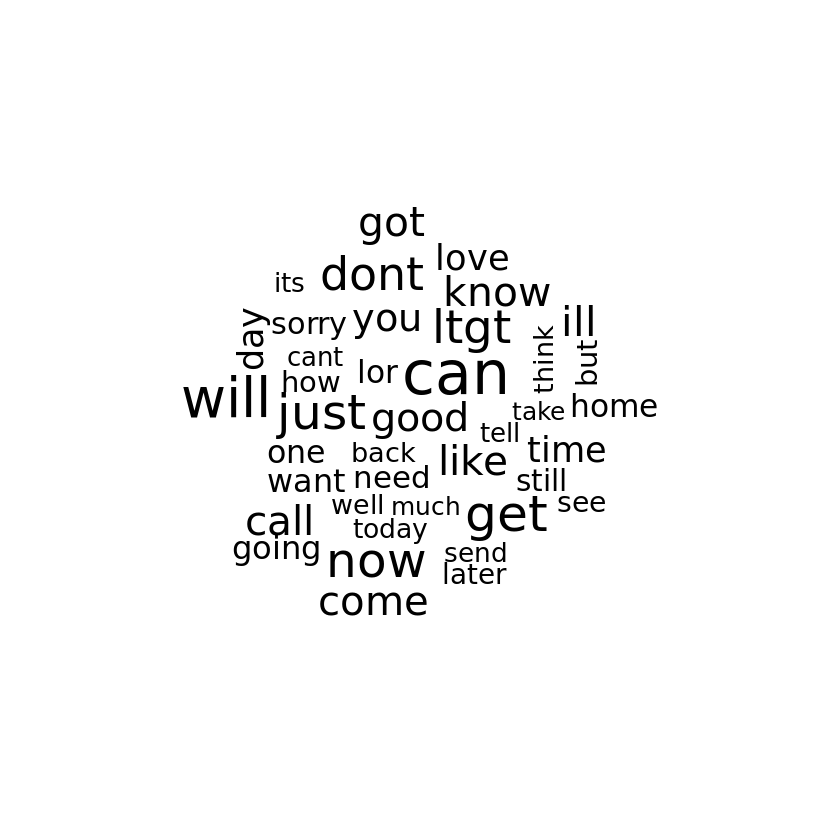

In [24]:
wordcloud(ham$text, max.words = 40, scale = c(3, 0.5))

In [25]:
##
## Palabras que aparecen al menos en 5 mensajes.
##
freq_words <- findFreqTerms(X_train, 5)
str(freq_words)

 chr [1:1157] "£wk" "abiola" "abl" "abt" "accept" "access" "account" ...


In [26]:
##
## Se construyen conjuntos de entrenamiento y prueba 
## con las palabras que aparecen al menos en 5 mensajes.
##
X_train <- X_train[ , freq_words]
X_test  <- X_test[  , freq_words]

In [27]:
##
## Se convierte la frecuencia de ocurrencia a "Yes" y "No"
##
convert_counts <- 
function(x) {
    x <- ifelse(x > 0, "Yes", "No")
}
##
X_train <- apply(X_train, MARGIN = 2, convert_counts)
X_test  <- apply(X_test,  MARGIN = 2, convert_counts)

## Entrenamiento del modelo

In [28]:
## Instalación del paquete
## install.packages("e1071")

In [29]:
##
## Carga la librería
##
library(e1071)
clf <- naiveBayes(X_train, y_train_true)

## Evaluación del modelo

In [30]:
##
## Se pronostica para los datos de prueba.
##
y_test_pred <- predict(clf, X_test)
head(y_test_pred)

[1] spam ham  ham  ham  ham  ham 
Levels: ham spam

In [33]:
##
## Se calcula la matriz de confusión.
##
table(y_test_true, y_test_pred)

           y_test_pred
y_test_true  ham spam
       ham  1200    9
       spam   20  161

In [34]:
##
## Se calcula la probabilidad de que cada mensaje sea 
## válido o spam para el conjunto de prueba. 
## Los resultados muestran que los mensajes
## son clasificados correctamente.
##
y_test_pred_prob <- predict(clf, X_test, type = "raw")
head(y_test_pred_prob)

ham,spam
1.142967e-14,1.000000e+00
9.963283e-01,3.671735e-03
9.999824e-01,1.764894e-05
1.000000e+00,8.310837e-09
9.999316e-01,6.839232e-05
9.999987e-01,1.301622e-06


In [35]:
##
## Resulta más conveniente preparar una nueva tabla que
## muestre la clasificación y no únicamente las 
## probabilidades.
##
results <- data.frame(actual_type  = y_test_true,
                      predict_type = y_test_pred,
                      prob_ham     = y_test_pred_prob[,1],
                      prob_spam    = y_test_pred_prob[,2])
head(results)

actual_type,predict_type,prob_ham,prob_spam
spam,spam,1.142967e-14,1.000000e+00
ham,ham,9.963283e-01,3.671735e-03
ham,ham,9.999824e-01,1.764894e-05
ham,ham,1.000000e+00,8.310837e-09
ham,ham,9.999316e-01,6.839232e-05
ham,ham,9.999987e-01,1.301622e-06


In [37]:
## install.packages("gmodels")
library(gmodels)
CrossTable(y_test_pred, 
           y_test_true,
           prop.chisq = FALSE, 
           prop.t = FALSE,
           dnn = c('predicted', 'actual'))


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|           N / Col Total |
|-------------------------|

 
Total Observations in Table:  1390 

 
             | actual 
   predicted |       ham |      spam | Row Total | 
-------------|-----------|-----------|-----------|
         ham |      1200 |        20 |      1220 | 
             |     0.984 |     0.016 |     0.878 | 
             |     0.993 |     0.110 |           | 
-------------|-----------|-----------|-----------|
        spam |         9 |       161 |       170 | 
             |     0.053 |     0.947 |     0.122 | 
             |     0.007 |     0.890 |           | 
-------------|-----------|-----------|-----------|
Column Total |      1209 |       181 |      1390 | 
             |     0.870 |     0.130 |           | 
-------------|-----------|-----------|-----------|

 


In [38]:
##
## Mensajes con clasificación errónea.
## Resulta muy importante determinar porque los 
## mensajes están mal clasificados
##
head(subset(results, actual_type != predict_type))

,actual_type,predict_type,prob_ham,prob_spam
45,spam,ham,0.988193712,0.011806288
54,ham,spam,0.003955372,0.996044628
85,ham,spam,0.277074268,0.722925732
88,spam,ham,0.988551588,0.011448412
130,spam,ham,0.993500148,0.006499852
205,spam,ham,0.895915228,0.104084772


In [39]:
##
## Sin embargo, es mucho más intersante extraer
## mensajes con probabilidades numéricamente 
## cercanas a 0.5. Estos podrían generar ambiguedad
## en la clasificación.
##
head(subset(results, prob_spam > 0.40 & prob_spam < 0.60))

,actual_type,predict_type,prob_ham,prob_spam
104,spam,spam,0.4885929,0.5114071
320,ham,spam,0.4702446,0.5297554
694,ham,spam,0.4916055,0.5083945
709,spam,spam,0.4885929,0.5114071
817,spam,spam,0.4885929,0.5114071
873,spam,spam,0.4885929,0.5114071


In [40]:
##
## Mensajes mal clasificados con probabilidad cercana a 0.5 
##
head(subset(results, prob_spam > 0.40 & prob_spam < 0.60 & actual_type != predict_type))

,actual_type,predict_type,prob_ham,prob_spam
320,ham,spam,0.4702446,0.5297554
694,ham,spam,0.4916055,0.5083945


**Ejercicio.--** El código presentado a continuación genera una curva ROC para este clasificador. Cómo se interpreta?

Loading required package: gplots

Attaching package: ‘gplots’

The following object is masked from ‘package:wordcloud’:

    textplot

The following object is masked from ‘package:stats’:

    lowess



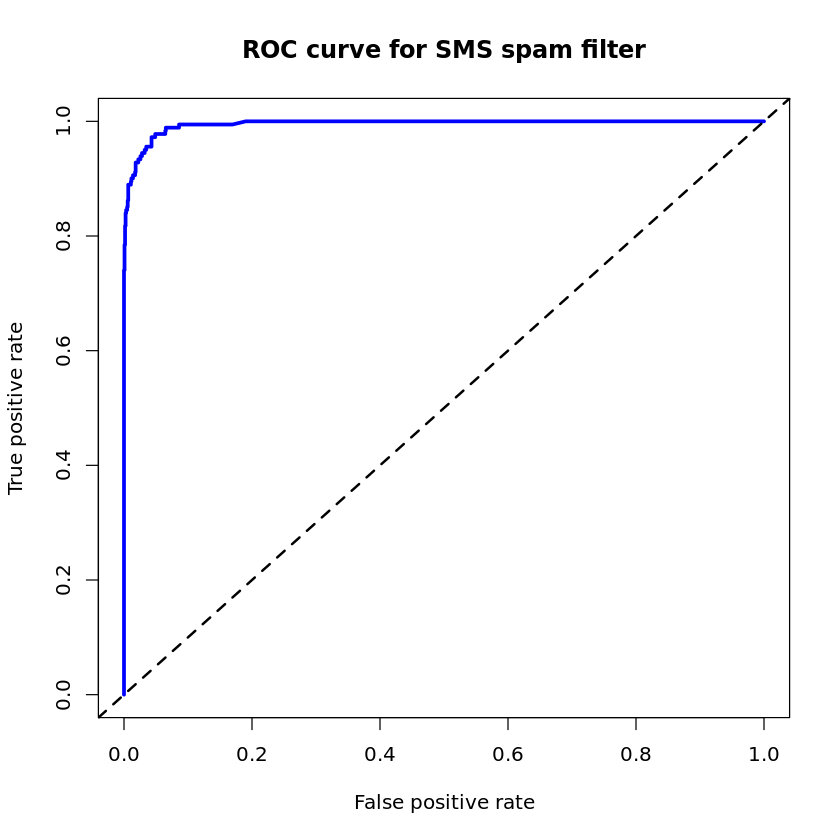

In [41]:
## install.packages("ROCR")
library(ROCR)
pred <- prediction(predictions = results$prob_spam,
                   labels = results$actual_type)
perf <- performance(pred, measure = "tpr", x.measure = "fpr")
plot(perf, 
     main = "ROC curve for SMS spam filter",
     col = "blue", 
     lwd = 3)
abline(a = 0, b = 1, lwd = 2, lty = 2)

In [42]:
##
## Se computa el área bajo la curva.
##
perf.auc <- performance(pred, measure = "auc")
unlist(perf.auc@y.values)

[1] 0.9950029

## Mejora del modelo

**Ejercicio.** Si en la construcción del clasificador se hace `laplace = 1`, en cuanto mejora la precisión del modelo. 

---